# Held-out NL→FOL faithfulness set: source re-verification (`data.py`) demo

This notebook demos **`data.py`**, the last step in building the *held-out NL→FOL faithfulness meta-evaluation set*
(dataset E). The set contains real first-order-logic (FOL) candidates for 700 sentences that are disjoint from the screen set.
The sentences come from **MALLS-train** (strata `L25` = ≥25 words with ≥3 conditions, `L20`, and `EXC` = unless/except/without) and
**FOLIO-train** (`CTRL`). The candidates come from 10 LLM slots plus ccg2lambda and the MALLS GPT-4 gold. Each candidate is labelled
`CORRECT / ERROR / CONTESTED / UNRESOLVED / UNPARSEABLE` by a z3 solver labeller combined with a blind, family-disjoint LLM panel.

`data.py` does **not** run the labelling pipeline, which lives in `src/`, costs money and uses API calls. It takes the assembled groups and
**re-checks every row against the original public source files**:

* the sentence and its reference FOL match the MALLS-v0.1-train record, or the FOLIO-v2-train premise and its folio-refined formula (`CTRL`);
* an LLM candidate's raw output matches its record in `generations.jsonl`;
* a ccg2lambda logical form appears in `kenken6696/folio_by_ccg2lambda` train;
* the `malls_gpt4_gold` candidate matches the MALLS gold.

It then stores `metadata_source_verified` and `metadata_source_file` on every row, never dropping rows. It validates the
`exp_sel_data_out` schema and writes `full_data_out.json` together with its `mini_` and `preview_` variants.

**Demo scope.** `mini_demo_data.json` holds 100 diverse rows of the main group, `heldout_candidates`. The rows are stratified over
source stratum × label and spread across all 13 generator systems. The file also holds **slices of the original source files** that the
verifier reads, so the verification code runs unchanged against real source data. The full artifact has 8,507 candidate rows and 3 more groups:
`heldout_sentences`, `panel_calibration` and `screen_audit`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# pandas, pyarrow, matplotlib — pre-installed on Colab, install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

## Imports
The original import block of `data.py`, unchanged, plus `matplotlib` for the final visualization.

In [2]:
from __future__ import annotations

import csv
import json
import re
import shutil
import sys
from collections import Counter
from pathlib import Path

import pandas as pd
from loguru import logger

# added for the notebook's results cell
import matplotlib.pyplot as plt

## Load the demo data
The data comes from the GitHub raw URL, with a fallback to the local `mini_demo_data.json`. The file holds:
* `datasets[0]` is the `heldout_candidates` group with 100 rows, each in `exp_sel_data_out` format (`input` JSON string, `output` label, `metadata_*` fields);
* `sources` holds the slices of the original source files that the verifier needs.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-1/dataset-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({d["dataset"]: len(d["examples"]) for d in data["datasets"]})
print({k: len(v) for k, v in data["sources"].items()})

{'heldout_candidates': 100}
{'malls_train': 60, 'generations': 88, 'folio_train_premises': 1678, 'refined_train_fols': 1680, 'refined_train_pairs': 1681, 'ccg_forms': 1638}


## Config
All tunable parameters are here.
* `N_EXAMPLES` sets how many `heldout_candidates` rows to verify. The demo file has 100, and the original run used all 8,507 rows in 4 groups.
* `MINI_K` is the number of examples per group in the `mini_` output. It is the default of `mini(obj, k=3)` in the original.
* `TRUNC_N` is the string truncation length in the `preview_` output. It is the default of `trunc(x, n=200)` in the original.

In [5]:
N_EXAMPLES = 100   # original: every row of every group (8,507 heldout_candidates + 2,046 rows in the other 3 groups)
MINI_K = 3         # original: 3
TRUNC_N = 200      # original: 200

## Setup: paths, logging, constants
The logic is the same as the original module header. One change: `ROOT` was the script's directory (`Path(__file__)`), and the demo writes
into `./demo_output/` so it does not overwrite anything. `TD` is where the original source datasets were symlinked. It is only used by the
original `load_sources()`, which the demo does not call. `LIMIT` is the 100 MB-per-file cap. Output larger than that is split into `full_data_out/full_data_out_{i}.json`.

In [6]:
ROOT = Path.cwd() / "demo_output"   # original: Path(__file__).resolve().parent
ROOT.mkdir(exist_ok=True)
TD = ROOT / "temp" / "datasets"
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")

GROUP_ORDER = ["heldout_candidates", "heldout_sentences", "panel_calibration", "screen_audit"]
FORBIDDEN = {"split", "dataset", "context"}
LIMIT = 100 * 1000 * 1000  # aii-file-size-limit: 100 MB per file

## Small helpers
`ws` collapses whitespace, and every comparison below runs on whitespace-normalised strings. `read_jsonl` reads a JSON-lines file.

In [7]:
def ws(s: str | None) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())


def read_jsonl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]

## Loading the source files
This is the original `load_sources()`, unchanged. It builds lookup tables from the public source files:
* `malls_train` maps MALLS-v0.1-train NL to gold FOL;
* `folio_train_premises` is the set of FOLIO-v2-train premises;
* `refined_train_fols` and `refined_train_pairs` hold the folio-refined train formulas and (NL, FOL) pairs; `refined_val_fols` holds the validation formulas;
* `gens` maps `(sentence_id, slot, prompt_variant)` to the raw LLM output recorded in `generations.jsonl`;
* `ccg_forms` holds the ccg2lambda logical forms of FOLIO train;
* `curated`, `curated_corrected_fols` and `logiclm_lines` are the DSAVlab-UNIUD curated records and the Logic-LM FOLIO-dev programs. They are used only by the `screen_audit` and `panel_calibration` checks.

Colab does not have these files, so the demo defines the function but does not call it.

In [8]:
def load_sources() -> dict:
    L = TD / "local_sources"
    src = {}
    src["malls_train"] = {ws(r["NL"]): ws(r["FOL"]) for r in json.load(open(L / "yuan-yang__MALLS-v0__MALLS-v0.1-train.json"))}
    src["folio_train_premises"] = {ws(p) for r in read_jsonl(TD / "tasksource__folio" / "folio_v2_train.jsonl") for p in r["premises"].split("\n")}
    refined, refined_pairs = set(), set()
    for r in csv.DictReader(open(L / "yfxiao__folio-refined__train.csv")):
        nls = [s for s in r["nl premises"].split("\n") if s.strip()]
        fols = [s for s in r["fol premises"].split("\n") if s.strip()]
        refined |= {ws(f) for f in fols}
        if len(nls) == len(fols):
            refined_pairs |= {(ws(n), ws(f)) for n, f in zip(nls, fols)}
    src["refined_train_fols"], src["refined_train_pairs"] = refined, refined_pairs
    src["refined_val_fols"] = {ws(f) for r in csv.DictReader(open(L / "folio_refined_validation.csv")) for f in r["fol premises"].split("\n") if f.strip()}
    src["gens"] = {(g["sentence_id"], g["slot"], g["prompt_variant"]): g["raw_output"]
                   for g in read_jsonl(TD / "generated_candidates" / "generations.jsonl") if g.get("raw_output") is not None}
    df = pd.read_parquet(TD / "kenken6696__folio_by_ccg2lambda" / "data" / "train-00000-of-00001.parquet")
    src["ccg_forms"] = {ws(x) for x in df["logical_form"]}
    cur = {}
    for f, newk in [("DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl", "FOL_sentence"),
                    ("DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl", "FOL_sentence_new")]:
        for r in read_jsonl(L / f):
            cur[str(r["id"])] = (ws(r["NL_sentence"]), ws(r["FOL_sentence_old"]), ws(r[newk]), f)
    src["curated"] = cur
    src["curated_corrected_fols"] = {v[2] for v in cur.values()}
    lines = set()
    for m in ("gpt-3.5-turbo", "gpt-4", "text-davinci-003"):
        for r in json.load(open(TD / "logiclm_FOLIO_dev_outputs" / f"FOLIO_dev_{m}.json")):
            prog = r["raw_logic_programs"][0] if isinstance(r["raw_logic_programs"], list) else r["raw_logic_programs"]
            for line in prog.splitlines():
                if ":::" in line:
                    fol, nl = line.strip().split(":::", 1)
                    lines.add((m, ws(fol), ws(nl)))
    src["logiclm_lines"] = lines
    return src

**Demo replacement for the file reads.** The function below builds a `src` dict with the same keys and types from the `sources` block of
`mini_demo_data.json`. The values were copied from the same files:
* the FOLIO premises, folio-refined train formulas and pairs, and ccg2lambda forms are the **complete** sets;
* the MALLS-train entries and `generations.jsonl` records are only those keyed by the 100 demo rows (the sentence text, and `(sentence_id, slot, prompt_variant)`).

The demo contains no `screen_audit` or `panel_calibration` rows, so the tables only those groups use stay empty.

In [9]:
def load_sources_from_demo(data: dict) -> dict:
    S = data["sources"]
    return {
        "malls_train": {ws(k): ws(v) for k, v in S["malls_train"].items()},
        "folio_train_premises": {ws(p) for p in S["folio_train_premises"]},
        "refined_train_fols": {ws(f) for f in S["refined_train_fols"]},
        "refined_train_pairs": {(ws(n), ws(f)) for n, f in S["refined_train_pairs"]},
        "refined_val_fols": set(),
        "gens": {(g["sentence_id"], g["slot"], g["prompt_variant"]): g["raw_output"] for g in S["generations"]},
        "ccg_forms": {ws(x) for x in S["ccg_forms"]},
        "curated": {}, "curated_corrected_fols": set(), "logiclm_lines": set(),
    }

## Per-group verifiers
These are the original functions, unchanged. Each returns `(ok, source_file_description)` for one row.

* **`verify_heldout`** (candidate rows, and sentence rows when `sentence_row=True`):
  * For `CTRL` the text must be a FOLIO-v2-train premise, and the reference must be its folio-refined formula, either as the exact (NL, FOL) pair or somewhere in the refined formula set.
  * For the MALLS strata the reference must equal the MALLS gold. The exception is a reference the panel repaired (`PANEL_REPAIRED`).
  * Then the candidate itself is checked. `malls_gpt4_gold` must equal the gold, a `ccg2lambda` raw logical form must be in the ccg2lambda dataset, and an LLM candidate's `metadata_raw_output` must be byte-identical to its `generations.jsonl` record.
* **`verify_screen`** (`screen_audit` rows): track H is checked against the curated DSAVlab-UNIUD record; track L requires the `(system, FOL ::: NL)` line to exist in the Logic-LM output.
* **`verify_calib`** (`panel_calibration` rows): synthetic gate items are checked against folio-refined; track H is checked against the curated record.

In [10]:
def verify_heldout(ex: dict, src: dict, sentence_row: bool = False) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    text = ws(inp["text"])
    stratum = ex["metadata_strata"]["source_stratum"]
    orig_ref = ws(ex.get("metadata_original_reference_fol") or inp["reference_fol"]) if sentence_row else None
    if stratum == "CTRL":
        ref = ws(inp["reference_fol"])
        ok = text in src["folio_train_premises"] and ((text, ref) in src["refined_train_pairs"] or ref in src["refined_train_fols"])
        file = "tasksource__folio/folio_v2_train.jsonl + local_sources/yfxiao__folio-refined__train.csv"
    else:
        gold = src["malls_train"].get(text)
        ref = orig_ref if sentence_row else ws(inp["reference_fol"])
        ok = gold is not None and (ref == gold or ex.get("metadata_reference_status") == "PANEL_REPAIRED")
        file = "local_sources/yuan-yang__MALLS-v0__MALLS-v0.1-train.json"
    if sentence_row or not ok:
        return ok, file
    sys_ = ex["metadata_system"]
    if sys_ == "malls_gpt4_gold":
        return ws(inp["candidate_fol"]) == src["malls_train"].get(text), file
    if sys_ == "ccg2lambda":
        return ws(ex["metadata_raw_output"]) in src["ccg_forms"], file + " + kenken6696__folio_by_ccg2lambda/train"
    raw = src["gens"].get((ex["metadata_sentence_id"], ex["metadata_slot"], ex["metadata_prompt_variant"]))
    return raw is not None and raw == ex["metadata_raw_output"], file + " + generated_candidates/generations.jsonl"


def verify_screen(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    if ex["metadata_track"] == "H":
        c = src["curated"].get(str(ex["metadata_record_id"]))
        ok = c is not None and c[0] == ws(inp["text"]) and c[1] == ws(inp["candidate_fol"]) and c[2] == ws(inp["reference_fol"])
        return ok, f"local_sources/{c[3] if c else 'DSAVlab-UNIUD curated'}"
    ok_line = (ex["metadata_system"], ws(inp["candidate_fol"]), ws(inp["text"])) in src["logiclm_lines"]
    ref = ws(inp["reference_fol"])
    ok_ref = ref in src["curated_corrected_fols"] or ref in src["refined_val_fols"]
    return ok_line and ok_ref, f"logiclm_FOLIO_dev_outputs/FOLIO_dev_{ex['metadata_system']}.json"


def verify_calib(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    if ex["metadata_subset"] == "synthetic_gate":
        text, ref = ws(inp["text"]), ws(inp["reference_fol"])
        return text in src["folio_train_premises"] and ((text, ref) in src["refined_train_pairs"] or ref in src["refined_train_fols"]), \
            "local_sources/yfxiao__folio-refined__train.csv"
    c = src["curated"].get(str(ex["metadata_record_id"]))
    ok = c is not None and c[0] == ws(inp["text"]) and c[1] == ws(inp["original_fol"]) and c[2] == ws(inp["corrected_fol"])
    return ok, f"local_sources/{c[3] if c else 'DSAVlab-UNIUD curated'}"

## Schema check and output writers
These are the original functions. The only change is that the defaults of `trunc` and `mini` now come from the config cell.
* `check_schema` enforces `exp_sel_data_out`: each group has only `dataset` and `examples`; `input` and `output` are strings; every other key is `metadata_*`; and the keys `split`, `dataset` and `context` are forbidden inside an example.
* `trunc` and `mini` build the `preview_` output (strings cut to `TRUNC_N` characters) and the `mini_` output (first `MINI_K` examples per group).
* `write_parts` runs only when the output exceeds `LIMIT`. It splits the output into numbered part files.

In [11]:
def check_schema(obj: dict) -> None:
    assert isinstance(obj.get("datasets"), list) and obj["datasets"]
    for d in obj["datasets"]:
        assert set(d) == {"dataset", "examples"} and d["examples"], d.get("dataset")
        for ex in d["examples"]:
            assert isinstance(ex["input"], str) and isinstance(ex["output"], str)
            for k in ex:
                assert k in ("input", "output") or (k.startswith("metadata_") and re.fullmatch(r"metadata_[a-zA-Z_][a-zA-Z0-9_]*", k)), k
                assert k not in FORBIDDEN


def trunc(x, n=TRUNC_N):   # original default: n=200
    if isinstance(x, str):
        return x if len(x) <= n else x[:n] + "..."
    if isinstance(x, list):
        return [trunc(v, n) for v in x]
    if isinstance(x, dict):
        return {k: trunc(v, n) for k, v in x.items()}
    return x


def mini(obj, k=MINI_K):   # original default: k=3
    return {"metadata": obj.get("metadata", {}), "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:k]} for d in obj["datasets"]]}


def write_parts(obj: dict) -> list[Path]:
    out = ROOT / "full_data_out"
    if out.exists():
        shutil.rmtree(out)
    out.mkdir()
    parts, cur, size = [], [], 0
    for d in obj["datasets"]:
        chunk = []
        for ex in d["examples"]:
            sz = len(json.dumps(ex, ensure_ascii=False).encode())
            if size + sz > LIMIT and (cur or chunk):
                if chunk:
                    cur.append({"dataset": d["dataset"], "examples": chunk})
                parts.append(cur); cur, chunk, size = [], [], 0
            chunk.append(ex); size += sz
        if chunk:
            cur.append({"dataset": d["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    paths = []
    for i, p in enumerate(parts, 1):
        o = {"metadata": {**obj["metadata"], "part": i, "n_parts": len(parts)}, "datasets": p}
        check_schema(o)
        f = out / f"full_data_out_{i}.json"
        f.write_text(json.dumps(o, ensure_ascii=False))
        (out / f"mini_full_data_out_{i}.json").write_text(json.dumps(mini(o), ensure_ascii=False, indent=1))
        (out / f"preview_full_data_out_{i}.json").write_text(json.dumps(trunc(mini(o)), ensure_ascii=False, indent=1))
        paths.append(f)
    m = mini(obj)
    (ROOT / "mini_data_out.json").write_text(json.dumps(m, ensure_ascii=False, indent=1))
    (ROOT / "preview_data_out.json").write_text(json.dumps(trunc(m), ensure_ascii=False, indent=1))
    return paths

## `main()`: verify every row and write the outputs
The flow is the original one. The input changes, and the steps are otherwise the same.
1. The groups come from the demo `data`, which holds the first `N_EXAMPLES` `heldout_candidates` rows. In the original they came from `work/assembled.json`, all 4 groups.
2. The source tables come from `load_sources_from_demo(data)` instead of `load_sources()`.
3. Each verifier runs for every group present. It sets `metadata_source_verified` and `metadata_source_file` on each row and counts verified, unverified and label totals. The original ran all 4 groups, and the demo skips any group that is absent.
4. The schema is validated and the output is written as one `full_data_out.json`, or split into parts above 100 MB, together with its mini and preview variants. The report is saved as `work/source_verification.json`.

In [12]:
@logger.catch(reraise=True)
def main() -> None:
    # original: A = json.loads((ROOT / "work" / "assembled.json").read_text(encoding="utf-8"))
    A = {"metadata": data["metadata"],
         "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:N_EXAMPLES]} for d in data["datasets"]]}
    groups = {d["dataset"]: d["examples"] for d in A["datasets"]}
    # original: assert list(groups) == GROUP_ORDER, list(groups)   (the demo only carries heldout_candidates)
    assert [g for g in GROUP_ORDER if g in groups] == list(groups), list(groups)
    src = load_sources_from_demo(data)   # original: src = load_sources()
    logger.info(f"sources loaded: MALLS-train {len(src['malls_train'])}, generations {len(src['gens'])}, Logic-LM lines {len(src['logiclm_lines'])}")
    report = {}
    for name, fn in [("heldout_candidates", lambda e: verify_heldout(e, src)),
                     ("heldout_sentences", lambda e: verify_heldout(e, src, sentence_row=True)),
                     ("panel_calibration", lambda e: verify_calib(e, src)),
                     ("screen_audit", lambda e: verify_screen(e, src))]:
        if name not in groups:   # demo: skip groups not in mini_demo_data.json
            continue
        c = Counter()
        for ex in groups[name]:
            ok, f = fn(ex)
            ex["metadata_source_verified"] = bool(ok)
            ex["metadata_source_file"] = f
            c[ok] += 1
        report[name] = {"rows": len(groups[name]), "verified": c[True], "unverified": c[False],
                        "labels": dict(Counter(e["output"] for e in groups[name]))}
        logger.info(f"{name}: {report[name]}")
    obj = {"metadata": {**A["metadata"], "source_verification": report,
                        "reading": "for f in sorted(glob('full_data_out/full_data_out_*.json')): concatenate each group's examples"},
           "datasets": [{"dataset": g, "examples": groups[g]} for g in GROUP_ORDER if g in groups]}
    check_schema(obj)
    blob = json.dumps(obj, ensure_ascii=False)
    if len(blob.encode()) <= LIMIT:
        if (ROOT / "full_data_out").exists():
            shutil.rmtree(ROOT / "full_data_out")
        (ROOT / "full_data_out.json").write_text(blob)
        m = mini(obj)
        (ROOT / "mini_data_out.json").write_text(json.dumps(m, ensure_ascii=False, indent=1))
        (ROOT / "preview_data_out.json").write_text(json.dumps(trunc(m), ensure_ascii=False, indent=1))
        paths = [ROOT / "full_data_out.json"]
    else:
        (ROOT / "full_data_out.json").unlink(missing_ok=True)
        paths = write_parts(obj)
    for p in paths:
        logger.info(f"{p.relative_to(ROOT)} {p.stat().st_size / 1e6:.2f} MB")
    (ROOT / "work").mkdir(exist_ok=True)   # added: the demo output dir has no work/ yet
    (ROOT / "work" / "source_verification.json").write_text(json.dumps(report, indent=1))

## Run it
`main()` overwrites `metadata_source_verified`. The cell first saves the flags the published artifact carried, so the results
can compare them with the flags recomputed here.

In [13]:
published_flags = {e["metadata_item_id"]: e["metadata_source_verified"] for e in data["datasets"][0]["examples"][:N_EXAMPLES]}
main()
report = json.loads((ROOT / "work" / "source_verification.json").read_text())
out = json.loads((ROOT / "full_data_out.json").read_text())
print(sorted(p.name for p in ROOT.iterdir()))

16:19:42|INFO   |sources loaded: MALLS-train 60, generations 88, Logic-LM lines 0


16:19:42|INFO   |heldout_candidates: {'rows': 100, 'verified': 100, 'unverified': 0, 'labels': {'UNPARSEABLE': 21, 'ERROR': 21, 'CORRECT': 22, 'CONTESTED': 21, 'UNRESOLVED': 15}}


16:19:42|INFO   |full_data_out.json 0.27 MB


['full_data_out.json', 'logs', 'mini_data_out.json', 'preview_data_out.json', 'work']


## Results
The table shows how many rows were verified, and whether each recomputed flag matches the flag in the published artifact.
The next cells show the label mix per source stratum, the label tiers, and the labels per generator family for the demo rows.
Tiers mean the following:
* **A**: decided by the z3 solver against a trusted reference.
* **B**: decided by the panel as a vocabulary/granularity (`VOCAB_GRAN`) or `COMPOUND` difference.
* **C**: no trusted reference.
* **`-`**: unparseable.
* **`none`**: unresolved.

The primary analysis in the dataset card uses tiers A+B, excluding `CONTESTED` and `reading_choice`, bootstrapped by `sentence_id`.

In [14]:
rows = out["datasets"][0]["examples"]
df = pd.DataFrame([{
    "item_id": e["metadata_item_id"],
    "stratum": e["metadata_strata"]["source_stratum"],
    "words": e["metadata_strata"]["words"],
    "n_conditions": e["metadata_strata"]["n_conditions"],
    "system": e["metadata_system"].split(":")[0],
    "family": e["metadata_family"],
    "variant": e["metadata_prompt_variant"],
    "label": e["output"],
    "tier": e["metadata_label_tier"],
    "verified": e["metadata_source_verified"],
    "matches_published": e["metadata_source_verified"] == published_flags[e["metadata_item_id"]],
    "source": e["metadata_source_file"].replace("local_sources/", "").replace("generated_candidates/", ""),
} for e in rows])

print("Verification report:", json.dumps(report, indent=1))
print(f"\nRecomputed flag == published flag for {df['matches_published'].sum()}/{len(df)} rows\n")
print(df.groupby("source")[["verified"]].agg(["sum", "count"]).to_string())
print()
print(pd.crosstab(df["stratum"], df["label"], margins=True).to_string())

Verification report: {
 "heldout_candidates": {
  "rows": 100,
  "verified": 100,
  "unverified": 0,
  "labels": {
   "UNPARSEABLE": 21,
   "ERROR": 21,
   "CORRECT": 22,
   "CONTESTED": 21,
   "UNRESOLVED": 15
  }
 }
}

Recomputed flag == published flag for 100/100 rows

                                                                                                                  verified      
                                                                                                                       sum count
source                                                                                                                          
tasksource__folio/folio_v2_train.jsonl + yfxiao__folio-refined__train.csv + generations.jsonl                           25    25
tasksource__folio/folio_v2_train.jsonl + yfxiao__folio-refined__train.csv + kenken6696__folio_by_ccg2lambda/train        4     4
yuan-yang__MALLS-v0__MALLS-v0.1-train.json                                        

In [15]:
# a few rows in full: sentence, candidate, reference, label
for _, r in df.drop_duplicates("label").head(4).iterrows():
    e = next(x for x in rows if x["metadata_item_id"] == r["item_id"])
    inp = json.loads(e["input"])
    print(f"[{e['output']} | tier {e['metadata_label_tier']} | {e['metadata_system']} | {r['stratum']}, {r['words']} words]")
    print("  text:     ", inp["text"][:220])
    print("  candidate:", (inp["candidate_fol"] or "<empty / unparseable>")[:220])
    print("  reference:", inp["reference_fol"][:220])
    print("  error_ops:", e["metadata_error_ops"], "| panel_votes:", e["metadata_panel_votes"], "\n")

[UNPARSEABLE | tier - | ccg2lambda | CTRL, 7 words]
  text:      When something is depressing, it is sad.
  candidate: <empty / unparseable>
  reference: ∀x (Depressing(x) → Sad(x))
  error_ops: None | panel_votes: None 

[ERROR | tier C | malls_gpt4_gold | L20, 20 words]
  text:      A location is classified as a desert if it experiences low precipitation, has extreme temperature variations, and supports minimal vegetation.
  candidate: ∀x (Location(x) ∧ LowPrecipitation(x) ∧ ExtremeTemperatureVariations(x) ∧ MinimalVegetation(x) → Desert(x))
  reference: ∀x (Location(x) ∧ LowPrecipitation(x) ∧ ExtremeTemperatureVariations(x) ∧ MinimalVegetation(x) → Desert(x))
  error_ops: ['ADD', 'DROP'] | panel_votes: {'P1': {'faithful': True, 'ops': [], 'conf': 5}, 'P3': {'faithful': False, 'ops': ['DROP', 'ADD'], 'conf': 5}, 'R1': {'faithful': False, 'ops': ['DROP'], 'conf': 4}} 

[CORRECT | tier A | F:openai/gpt-5.1 | CTRL, 7 words]
  text:      When something is depressing, it is sad.
  candida

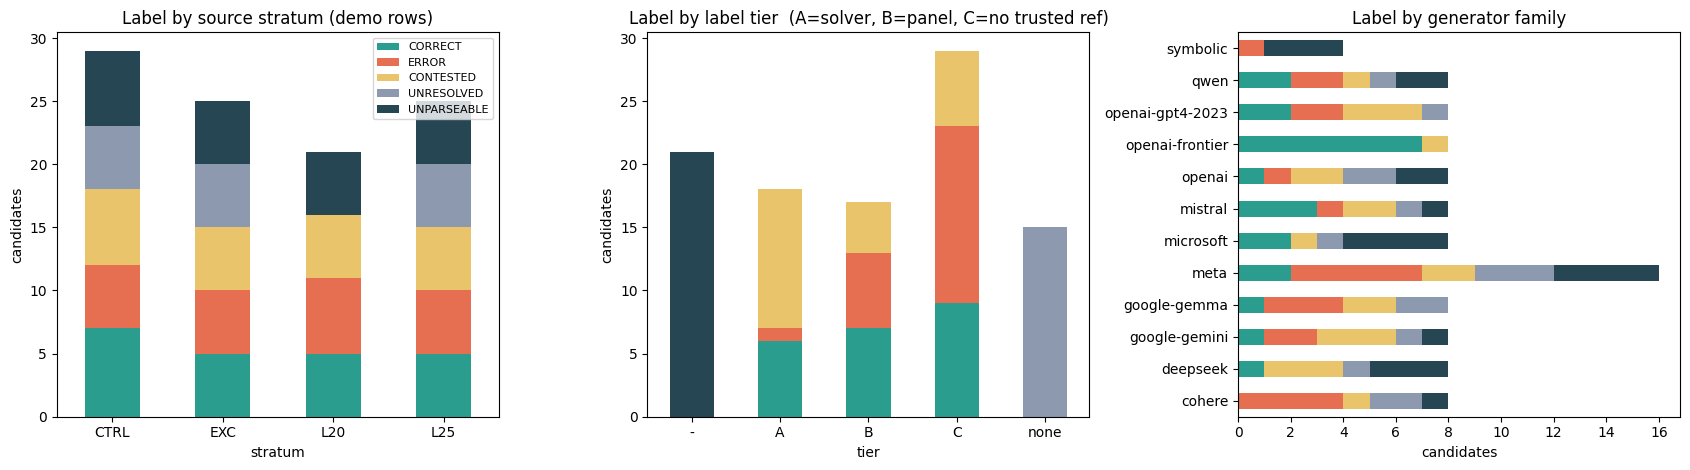

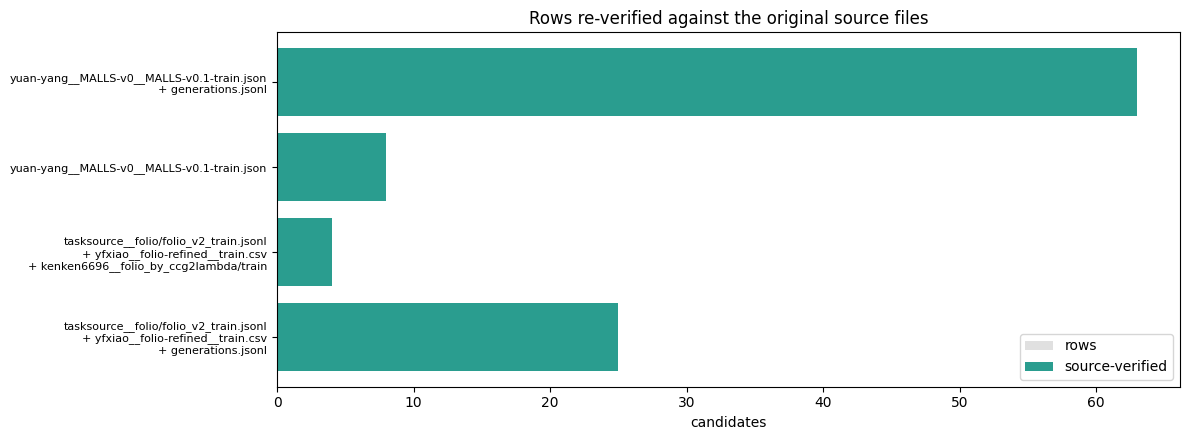

In [16]:
LABELS = ["CORRECT", "ERROR", "CONTESTED", "UNRESOLVED", "UNPARSEABLE"]
COLORS = {"CORRECT": "#2a9d8f", "ERROR": "#e76f51", "CONTESTED": "#e9c46a", "UNRESOLVED": "#8d99ae", "UNPARSEABLE": "#264653"}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

ct = pd.crosstab(df["stratum"], df["label"]).reindex(columns=LABELS, fill_value=0)
ct.plot(kind="bar", stacked=True, ax=axes[0], color=[COLORS[l] for l in LABELS], rot=0)
axes[0].set_title("Label by source stratum (demo rows)"); axes[0].set_ylabel("candidates"); axes[0].legend(fontsize=8)

ct = pd.crosstab(df["tier"], df["label"]).reindex(columns=LABELS, fill_value=0)
ct.plot(kind="bar", stacked=True, ax=axes[1], color=[COLORS[l] for l in LABELS], rot=0, legend=False)
axes[1].set_title("Label by label tier  (A=solver, B=panel, C=no trusted ref)"); axes[1].set_ylabel("candidates")

ct = pd.crosstab(df["family"], df["label"]).reindex(columns=LABELS, fill_value=0)
ct.plot(kind="barh", stacked=True, ax=axes[2], color=[COLORS[l] for l in LABELS], legend=False)
axes[2].set_title("Label by generator family"); axes[2].set_xlabel("candidates"); axes[2].set_ylabel("")

plt.tight_layout(); plt.show()

# source verification: verified rows per source file
v = df.groupby("source")["verified"].agg(["sum", "count"])
v.index = [s.replace(" + ", "\n+ ") for s in v.index]   # wrap long source-file names
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.barh(v.index, v["count"], color="#e0e0e0", label="rows")
ax.barh(v.index, v["sum"], color="#2a9d8f", label="source-verified")
ax.set_xlabel("candidates")
ax.set_title("Rows re-verified against the original source files"); ax.legend(loc="lower right"); ax.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()